<a href="https://colab.research.google.com/github/eduardo-aoyama/customer-funnel-analysis/blob/main/analysis_cf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Funnel Analysis

## Objective

Analyze user conversion through different stages of the funnel.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("customer_funnel.csv")
df.head()

,user_id,visit_date,signup_date,first_purchase_date,second_purchase_date
0,1,2025-01-01,2025-01-02,2025-01-05,2025-01-20
1,2,2025-01-01,NaN,NaN,NaN
2,3,2025-01-02,2025-01-03,NaN,NaN
3,4,2025-01-02,2025-01-04,2025-01-10,NaN
4,5,2025-01-03,2025-01-05,2025-01-08,2025-01-25


In [3]:
funnel = {
    "Visited": df['user_id'].nunique(),
    "Signed Up": df['signup_date'].notna().sum(),
    "First Purchase": df['first_purchase_date'].notna().sum(),
    "Second Purchase": df['second_purchase_date'].notna().sum()
}

funnel_df = pd.DataFrame(list(funnel.items()), columns=['Stage', 'Users'])
funnel_df

,Stage,Users
0,Visited,20
1,Signed Up,15
2,First Purchase,10
3,Second Purchase,5


In [4]:
funnel_df['Conversion Rate'] = funnel_df['Users'] / funnel_df['Users'].iloc[0]
funnel_df

,Stage,Users,Conversion Rate
0,Visited,20,1.00
1,Signed Up,15,0.75
2,First Purchase,10,0.50
3,Second Purchase,5,0.25


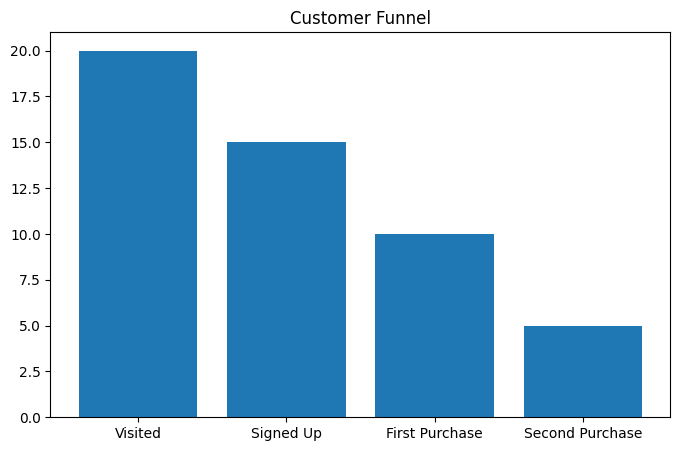

In [5]:
plt.figure(figsize=(8,5))
plt.bar(funnel_df['Stage'], funnel_df['Users'])
plt.title("Customer Funnel")
plt.show()

## Key Insights

- There is a significant drop between visit and signup
- Conversion improves after signup
- Retention to second purchase is low

## Business Interpretation

The main bottleneck is converting visitors into users, suggesting improvements in onboarding or product value communication.